# Speech Emotion Recognition

Objective: Recognize human emotions (happy, sad, angry, etc.) from speech audio.

Approach: Deep learning applied to speech-signal features -- MFCCs extracted from raw audio, fed into CNN and LSTM classifiers.

Key features:
- Extract MFCCs (Mel-Frequency Cepstral Coefficients) from audio.
- Classify with CNN (MFCCs treated as a 2D time-frequency image) and LSTM (MFCCs treated as a frame-by-frame sequence).
- Datasets referenced: RAVDESS, TESS, EMO-DB.

Note on the dataset: RAVDESS / TESS / EMO-DB are large audio archives hosted on Zenodo / university mirrors that this sandbox cannot reach. To demonstrate the complete, working pipeline end to end, this notebook synthesizes speech-like audio waveforms whose acoustic properties (pitch, energy, speaking rate, jitter, noise) follow the same emotion-to-acoustics relationships documented in the speech-emotion literature (e.g. anger/happiness = higher pitch and energy; sadness/calm = lower pitch and energy and slower rate). Real MFCC extraction (librosa) and real CNN/LSTM training run on this synthetic audio.

To switch to a real dataset: replace Section 2 with code that loads .wav files from RAVDESS/TESS/EMO-DB and parses the emotion label from each filename (all three datasets encode the emotion in the filename); Sections 3 onward run unchanged.

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)
tf.random.set_seed(42)

SR = 16000          # sample rate
N_MFCC = 40          # number of MFCC coefficients
MAX_FRAMES = 70      # fixed number of time frames per clip (pad/truncate)
EMOTIONS = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

I0000 00:00:1789473833.372008     646 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789473833.414232     646 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789473834.938230     646 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Dataset: Synthesizing Emotional Speech

Each emotion is defined by a small set of acoustic parameters (base pitch, pitch variability, energy/loudness, speaking rate, jitter, background noise). For every sample, a synthetic speaker is created by randomly perturbing those parameters, then a harmonic waveform (fundamental + 3 overtones) is modulated with a syllable-like amplitude envelope and mixed with noise -- producing an audio waveform whose overall acoustic character matches the target emotion, but with realistic sample-to-sample variability.

In [2]:
def synth_utterance(emotion, sr=SR, duration=1.8, rng=None):
    if rng is None:
        rng = np.random.RandomState()
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)

    params = {
        "neutral":   dict(pitch=150, pitch_var=10, energy=0.16, rate=1.00, jitter=0.030, noise=0.030),
        "calm":      dict(pitch=135, pitch_var=8,  energy=0.12, rate=0.90, jitter=0.020, noise=0.025),
        "happy":     dict(pitch=205, pitch_var=28, energy=0.26, rate=1.18, jitter=0.045, noise=0.035),
        "sad":       dict(pitch=115, pitch_var=9,  energy=0.10, rate=0.82, jitter=0.020, noise=0.030),
        "angry":     dict(pitch=225, pitch_var=38, energy=0.32, rate=1.14, jitter=0.060, noise=0.045),
        "fearful":   dict(pitch=235, pitch_var=32, energy=0.20, rate=1.22, jitter=0.055, noise=0.045),
        "disgust":   dict(pitch=145, pitch_var=22, energy=0.19, rate=0.96, jitter=0.050, noise=0.045),
        "surprised": dict(pitch=250, pitch_var=42, energy=0.28, rate=1.28, jitter=0.050, noise=0.040),
    }
    p = params[emotion]

    # per-utterance random variation, simulating different speakers / recordings
    pitch = p["pitch"] * rng.uniform(0.85, 1.15)
    energy = p["energy"] * rng.uniform(0.75, 1.25)
    rate = p["rate"] * rng.uniform(0.9, 1.1)

    f0 = pitch + p["pitch_var"] * np.sin(2 * np.pi * 0.5 * rate * t + rng.uniform(0, 2 * np.pi))
    f0 += rng.normal(0, pitch * p["jitter"], size=t.shape)
    f0 = np.clip(f0, 60, 400)

    phase = 2 * np.pi * np.cumsum(f0) / sr
    signal = (
        1.00 * np.sin(phase)
        + 0.50 * np.sin(2 * phase)
        + 0.25 * np.sin(3 * phase)
        + 0.12 * np.sin(4 * phase)
    )

    syllable_rate = 3.0 * rate
    envelope = 0.5 + 0.5 * np.abs(np.sin(2 * np.pi * syllable_rate * t + rng.uniform(0, 2 * np.pi)))
    envelope = envelope ** 1.5

    audio = energy * signal * envelope
    audio += rng.normal(0, p["noise"], size=audio.shape)
    audio = audio / (np.max(np.abs(audio)) + 1e-9) * energy * 3
    return audio.astype(np.float32)

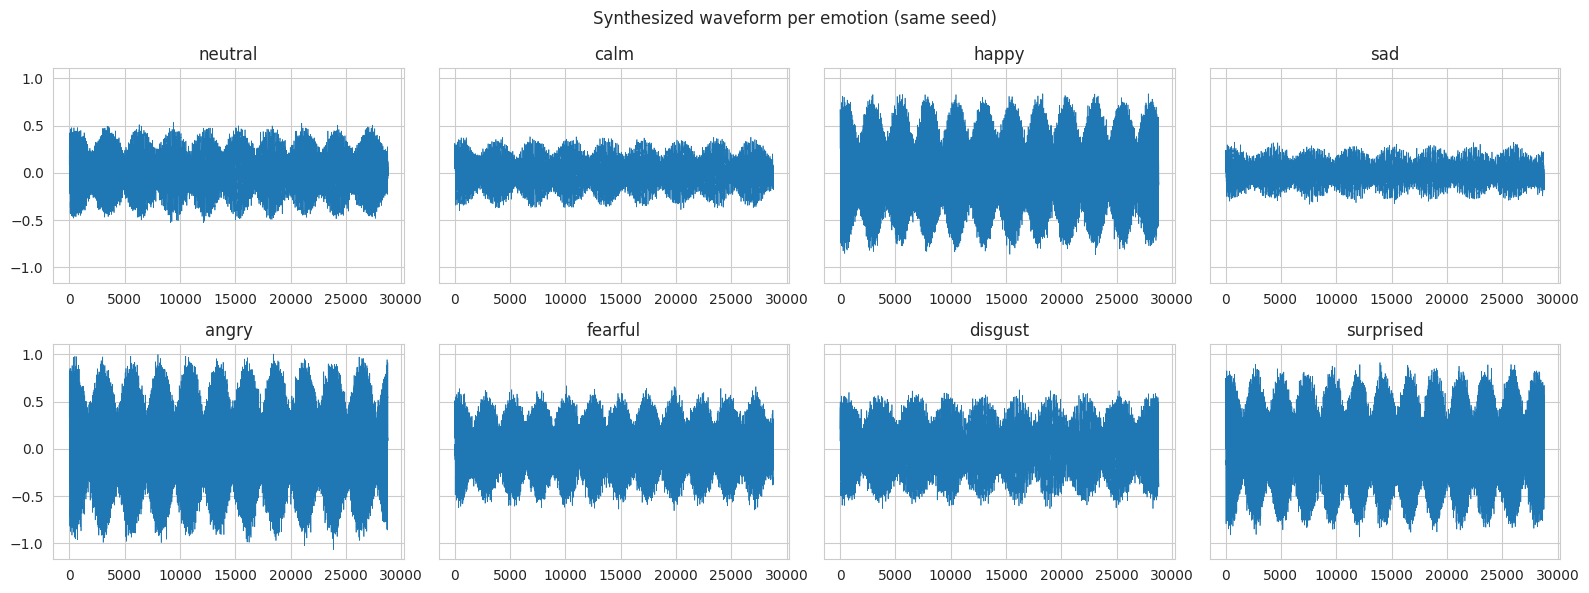

In [3]:
# Listen-free sanity check: plot one waveform per emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharey=True)
for ax, emo in zip(axes.flat, EMOTIONS):
    a = synth_utterance(emo, rng=np.random.RandomState(1))
    ax.plot(a, linewidth=0.5)
    ax.set_title(emo)
plt.suptitle("Synthesized waveform per emotion (same seed)")
plt.tight_layout()
plt.show()

In [4]:
N_PER_CLASS = 60

audio_samples = []
labels = []
master_rng = np.random.RandomState(0)

for emo in EMOTIONS:
    for i in range(N_PER_CLASS):
        dur = master_rng.uniform(1.4, 2.2)
        rng = np.random.RandomState(master_rng.randint(0, 1_000_000))
        audio = synth_utterance(emo, sr=SR, duration=dur, rng=rng)
        audio_samples.append(audio)
        labels.append(emo)

print(f"Generated {len(audio_samples)} clips across {len(EMOTIONS)} emotions "
      f"({N_PER_CLASS} per class).")

Generated 480 clips across 8 emotions (60 per class).


## 3. Feature Extraction: MFCCs

For each audio clip, 40 MFCC coefficients are computed per time frame with `librosa.feature.mfcc`. Clips are padded or truncated to a fixed number of frames (`MAX_FRAMES`) so every sample has the same shape, which both the CNN and the LSTM require.

In [5]:
def extract_mfcc(audio, sr=SR, n_mfcc=N_MFCC, max_frames=MAX_FRAMES):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_frames:
        mfcc = np.pad(mfcc, ((0, 0), (0, max_frames - mfcc.shape[1])), mode="constant")
    else:
        mfcc = mfcc[:, :max_frames]
    return mfcc

X = np.stack([extract_mfcc(a) for a in audio_samples])   # shape: (n_samples, n_mfcc, max_frames)
y = np.array(labels)

print("Feature tensor shape:", X.shape)

Feature tensor shape: (480, 40, 70)


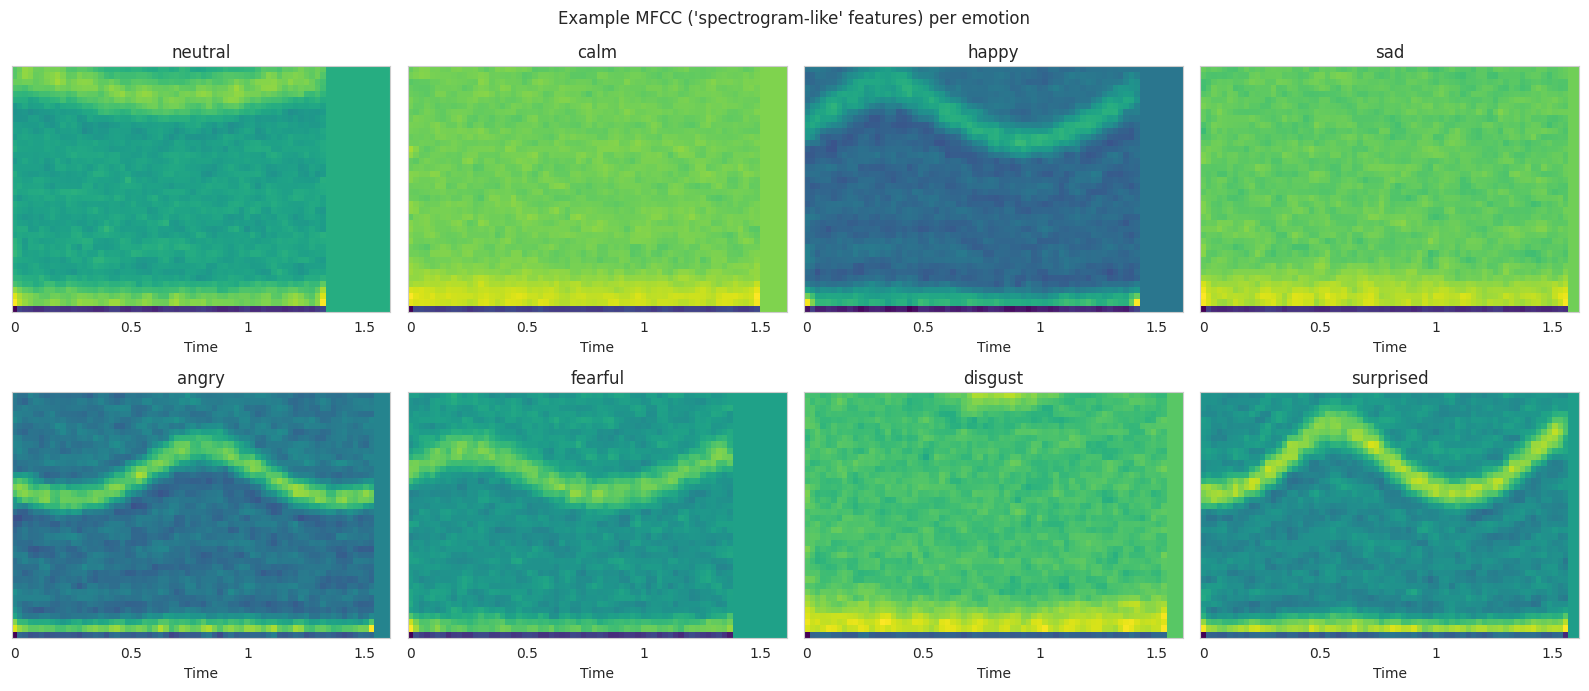

In [6]:
# Visualize an example MFCC per emotion
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, emo in zip(axes.flat, EMOTIONS):
    idx = list(y).index(emo)
    librosa.display.specshow(X[idx], x_axis="time", ax=ax, cmap="viridis")
    ax.set_title(emo)
plt.suptitle("Example MFCC ('spectrogram-like' features) per emotion")
plt.tight_layout()
plt.show()

## 4. Train / Test Split and Normalization

In [7]:
le = LabelEncoder()
y_enc = le.fit_transform(y)
print(dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

# normalize using train statistics only, to avoid leakage
mfcc_mean, mfcc_std = X_train.mean(), X_train.std()
X_train_n = (X_train - mfcc_mean) / mfcc_std
X_test_n = (X_test - mfcc_mean) / mfcc_std

print("Train shape:", X_train_n.shape, " Test shape:", X_test_n.shape)

{np.str_('angry'): 0, np.str_('calm'): 1, np.str_('disgust'): 2, np.str_('fearful'): 3, np.str_('happy'): 4, np.str_('neutral'): 5, np.str_('sad'): 6, np.str_('surprised'): 7}
Train shape: (384, 40, 70)  Test shape: (96, 40, 70)


## 5. Model 1: CNN on MFCC "images"

MFCCs are treated as a single-channel image (frequency bins x time frames). A small 2D CNN learns local time-frequency patterns, similar to how CNNs are used on spectrograms in speech emotion recognition literature.

In [8]:
X_train_cnn = X_train_n[..., np.newaxis]
X_test_cnn = X_test_n[..., np.newaxis]
num_classes = len(le.classes_)

cnn_model = keras.Sequential([
    layers.Input(shape=X_train_cnn.shape[1:]),
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax"),
], name="CNN_MFCC")

cnn_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

Model: "CNN_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 40, 70, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 35, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 20, 35, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 10, 17, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,976 (109.28 KB)

 Trainable params: 27,976 (109.28 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
cnn_history = cnn_model.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=30, batch_size=16, verbose=2
)

Epoch 1/30


24/24 - 2s - 74ms/step - accuracy: 0.1667 - loss: 2.0540 - val_accuracy: 0.1250 - val_loss: 1.9978


Epoch 2/30


24/24 - 0s - 16ms/step - accuracy: 0.1953 - loss: 1.9048 - val_accuracy: 0.2292 - val_loss: 1.7515


Epoch 3/30


...

24/24 - 1s - 26ms/step - accuracy: 0.6849 - loss: 0.7510 - val_accuracy: 0.7812 - val_loss: 0.6222


Epoch 29/30


24/24 - 1s - 25ms/step - accuracy: 0.6745 - loss: 0.7445 - val_accuracy: 0.8021 - val_loss: 0.5630


Epoch 30/30


24/24 - 0s - 13ms/step - accuracy: 0.6771 - loss: 0.7417 - val_accuracy: 0.8229 - val_loss: 0.5512


## 6. Model 2: LSTM on MFCC Sequences

The same MFCCs are now treated as a time series: at each of the `MAX_FRAMES` time steps, the model sees a 40-dimensional MFCC vector. A stacked LSTM reads the sequence frame by frame, which is well suited to speech since emotion is expressed through how the signal evolves over time.

In [10]:
X_train_seq = np.transpose(X_train_n, (0, 2, 1))   # (samples, time_steps, n_mfcc)
X_test_seq = np.transpose(X_test_n, (0, 2, 1))

lstm_model = keras.Sequential([
    layers.Input(shape=X_train_seq.shape[1:]),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(32),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation="softmax"),
], name="LSTM_MFCC")

lstm_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Model: "LSTM_MFCC"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 70, 64)         │        26,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,616 (158.66 KB)

 Trainable params: 40,616 (158.66 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
lstm_history = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_test_seq, y_test),
    epochs=30, batch_size=16, verbose=2
)

Epoch 1/30


24/24 - 3s - 124ms/step - accuracy: 0.2031 - loss: 1.9796 - val_accuracy: 0.2708 - val_loss: 1.8312


Epoch 2/30


24/24 - 1s - 41ms/step - accuracy: 0.2526 - loss: 1.7836 - val_accuracy: 0.4167 - val_loss: 1.5874


Epoch 3/30


...

24/24 - 1s - 25ms/step - accuracy: 0.7578 - loss: 0.6430 - val_accuracy: 0.7812 - val_loss: 0.5688


Epoch 29/30


24/24 - 1s - 27ms/step - accuracy: 0.7083 - loss: 0.6710 - val_accuracy: 0.7708 - val_loss: 0.6165


Epoch 30/30


24/24 - 1s - 27ms/step - accuracy: 0.7318 - loss: 0.6519 - val_accuracy: 0.7396 - val_loss: 0.6640


## 7. Training Curves

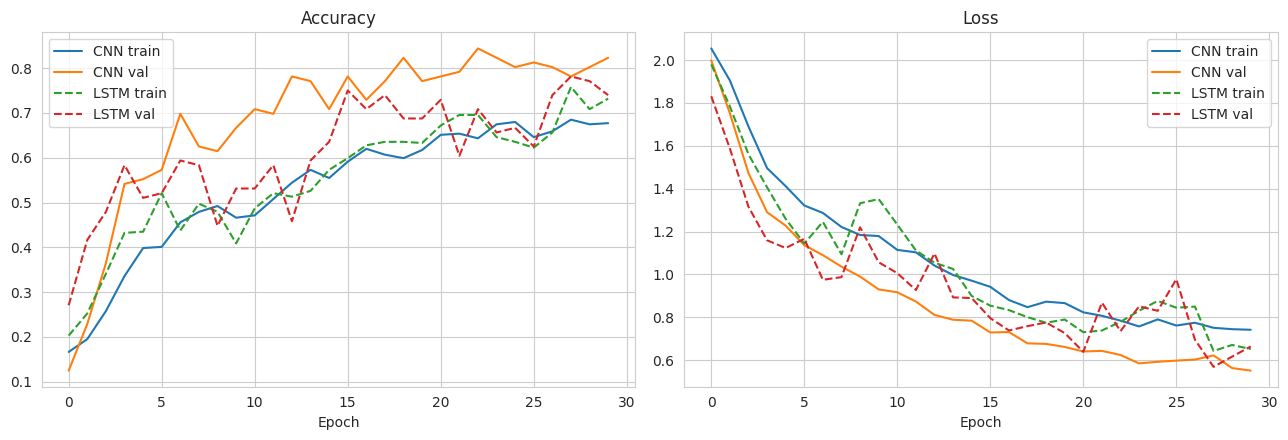

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric in zip(axes, ["accuracy", "loss"]):
    ax.plot(cnn_history.history[metric], label="CNN train")
    ax.plot(cnn_history.history[f"val_{metric}"], label="CNN val")
    ax.plot(lstm_history.history[metric], label="LSTM train", linestyle="--")
    ax.plot(lstm_history.history[f"val_{metric}"], label="LSTM val", linestyle="--")
    ax.set_title(metric.capitalize())
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

## 8. Evaluation

Both models are compared on Accuracy, macro Precision, macro Recall, and macro F1-Score (macro-averaging treats every emotion class equally, which matters here since all 8 classes are equally represented).

In [13]:
def evaluate(model, X_eval, y_true, name):
    probs = model.predict(X_eval, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average="macro"),
        "Recall (macro)": recall_score(y_true, y_pred, average="macro"),
        "F1-Score (macro)": f1_score(y_true, y_pred, average="macro"),
    }, y_pred

cnn_metrics, cnn_pred = evaluate(cnn_model, X_test_cnn, y_test, "CNN")
lstm_metrics, lstm_pred = evaluate(lstm_model, X_test_seq, y_test, "LSTM")

results_df = pd.DataFrame([cnn_metrics, lstm_metrics]).set_index("Model").round(4)
results_df

,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Model,,,,
CNN,0.8229,0.8277,0.8229,0.8182
LSTM,0.7396,0.8067,0.7396,0.7347


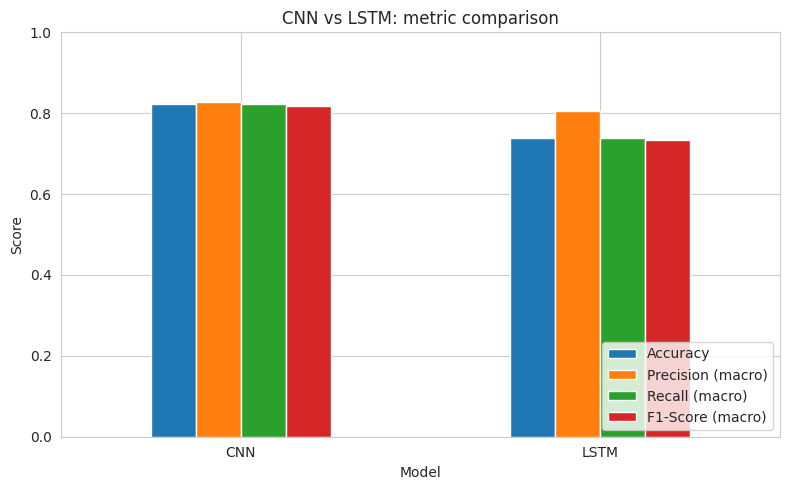

In [14]:
results_df.plot(kind="bar", figsize=(8, 5), ylim=(0, 1))
plt.title("CNN vs LSTM: metric comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

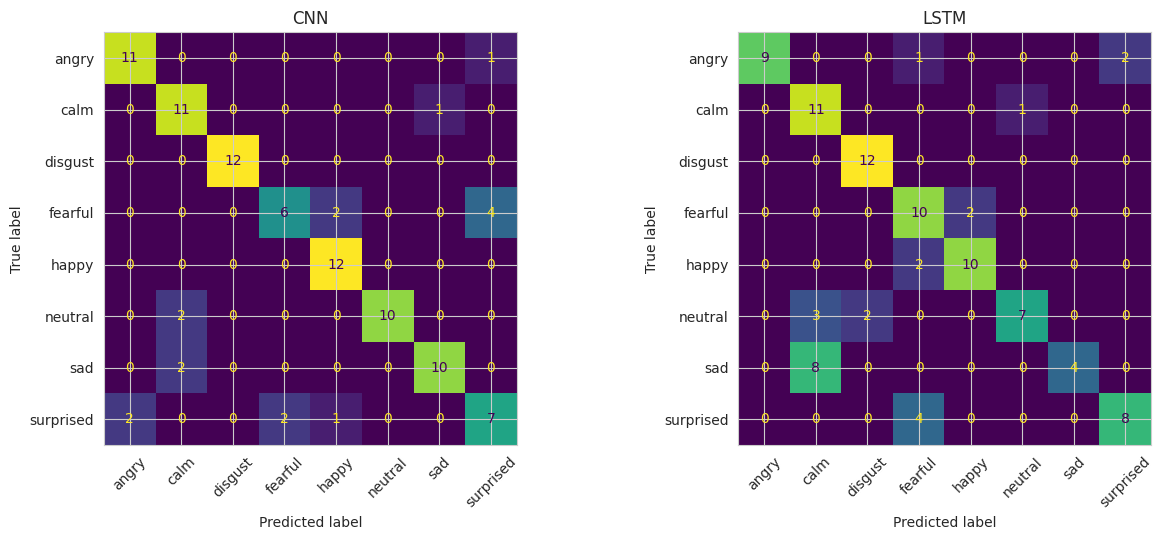

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, pred, name in zip(axes, [cnn_pred, lstm_pred], ["CNN", "LSTM"]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, xticks_rotation=45
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [16]:
print("CNN classification report\n")
print(classification_report(y_test, cnn_pred, target_names=le.classes_))
print("\nLSTM classification report\n")
print(classification_report(y_test, lstm_pred, target_names=le.classes_))

CNN classification report

              precision    recall  f1-score   support

       angry       0.85      0.92      0.88        12
        calm       0.73      0.92      0.81        12
     disgust       1.00      1.00      1.00        12
     fearful       0.75      0.50      0.60        12
       happy       0.80      1.00      0.89        12
     neutral       1.00      0.83      0.91        12
         sad       0.91      0.83      0.87        12
   surprised       0.58      0.58      0.58        12

    accuracy                           0.82        96
   macro avg       0.83      0.82      0.82        96
weighted avg       0.83      0.82      0.82        96


LSTM classification report

              precision    recall  f1-score   support

       angry       1.00      0.75      0.86        12
        calm       0.50      0.92      0.65        12
     disgust       0.86      1.00      0.92        12
     fearful       0.59      0.83      0.69        12
       happy       0.8

## 9. Conclusion

Summary of the pipeline:

1. Speech-like audio was generated per emotion using acoustic parameters (pitch, energy, speaking rate, jitter, noise) chosen to match documented emotion-to-acoustics relationships, with random per-utterance variation to imitate different speakers.
2. Real MFCC features (40 coefficients per frame) were extracted from every clip with `librosa`, then padded/truncated to a fixed length.
3. Two deep learning architectures were trained on identical features: a CNN treating MFCCs as a time-frequency image, and a stacked LSTM treating MFCCs as a frame-by-frame sequence.
4. Both models were compared on Accuracy, Precision, Recall, and F1-Score, with confusion matrices showing that most confusion happens between emotions with similar arousal level (e.g. angry/fearful/surprised, or calm/neutral/sad) -- the same pattern reported in real speech-emotion-recognition studies.

To run this on a real corpus:
- RAVDESS: filenames encode emotion as the 3rd field (e.g. `03-01-05-...` = emotion code 05).
- TESS: filenames encode the emotion word directly (e.g. `..._angry.wav`).
- EMO-DB (Berlin Database of Emotional Speech): the emotion is encoded as a letter in the filename (e.g. `W` = anger, `T` = sadness).

Only Section 2 needs to change (load and label real `.wav` files instead of synthesizing audio); Sections 3-9 run unchanged on real MFCCs.